# Exercise 1a (Dataset description)

**It contains elements:**
- movies.dat (10197 movies)  
    -> movies + extra data 
- tags.dat (13222 tags)  
    -> assigns id to every tag 


**and assignments:**
- movie_actors.dat (95321 actors)  
    -> combines movies/actors with (movieID/actorID)
- movie_genres.dat (20 genres)  
    -> links movies/genres with (movieID/genre)
- movie_directors.dat (4060 directors)  
    -> links movie/directors with (movieID/directorID)
- movie_countries.dat (72 countries)  
    -> (movieID/country)
- user_taggedmovies.dat - user_taggedmovies-timestamps.dat (47957 assignments)  
    -> assignments which user tagged which film (userID	movieID	tagID)
- movie_tags.dat  
    -> (movieID/tagID)
- user_ratedmovies.dat - user_ratedmovies-timestamps.dat  
    -> (userID/movieID)+rating(value)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

path = "./hetrec2011-movielens-2k-v2/"

movies = pd.read_csv(path + 'movies.dat', sep='\t', encoding='latin-1')
tags = pd.read_csv(path + 'tags.dat', sep='\t', encoding='latin-1')


directors = pd.read_csv(path + 'movie_directors.dat', sep='\t', encoding='latin-1')
actors = pd.read_csv(path + 'movie_actors.dat', sep='\t', encoding='latin-1')
ratings = pd.read_csv(path + 'user_ratedmovies.dat', sep='\t', encoding='latin-1')

movie_genres = pd.read_csv(path + 'movie_genres.dat', sep='\t', encoding='latin-1')
movie_tags = pd.read_csv(path + 'movie_tags.dat', sep='\t', encoding='latin-1')
user_tagged = pd.read_csv(path + 'user_taggedmovies.dat', sep='\t', encoding='latin-1')


movie_tags_merged = movie_tags.merge(tags,
    left_on="tagID",
    right_on="id")

def weighted_tags(group):
    tags = []
    for _, row in group.iterrows():
        tags.extend([str(row["value"])] * int(round(row["tagWeight"])))
    return " ".join(tags)

movie_tags_weight_extension = movie_tags_merged.groupby("id").apply(weighted_tags)
movie_tags_weight_extension = movie_tags_weight_extension.reindex(movies["id"], fill_value="")


C:\Users\jonas\AppData\Local\Temp\ipykernel_17244\2086277976.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  movie_tags_weight_extension = movie_tags_merged.groupby("id").apply(weighted_tags)


## b) 

Genre feature shape: (10197, 20)
Genre sparsity: 0.897965087770913


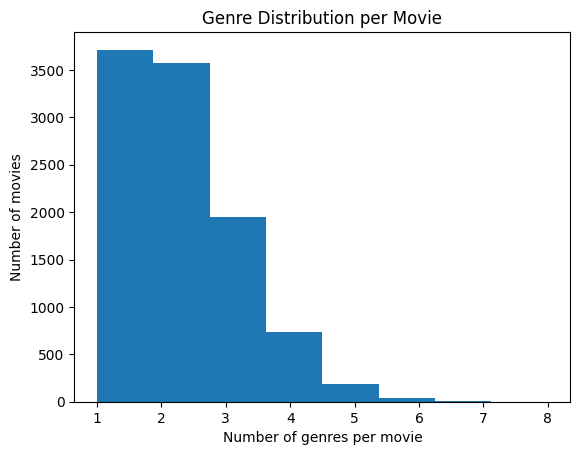

In [17]:
genre_grouped = movie_genres.groupby("movieID")["genre"].apply(list)

mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(genre_grouped)

genre_df = pd.DataFrame(genre_features, 
                        index=genre_grouped.index,
                        columns=mlb.classes_)

print("Genre feature shape:", genre_df.shape)

genre_sparsity = (genre_df == 0).sum().sum() / genre_df.size
print("Genre sparsity:", genre_sparsity)

plt.hist(genre_df.sum(axis=1), bins=8)
plt.xlabel("Number of genres per movie")
plt.ylabel("Number of movies")
plt.title("Genre Distribution per Movie")
plt.show()

Tag feature shape: (10197, 5000)
Tag sparsity: 0.9985750514857311


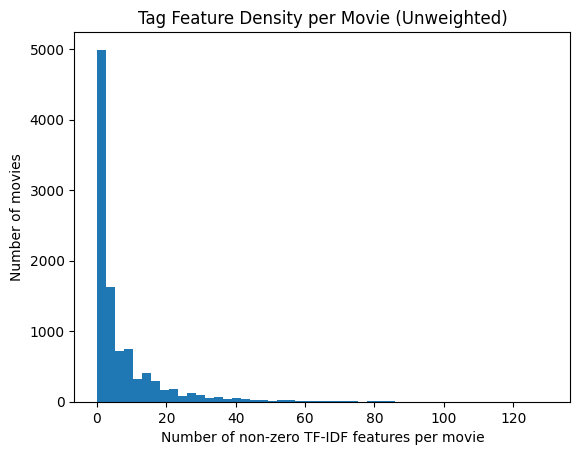

In [ ]:
tag_grouped = movie_tags_merged.groupby("movieID")["value"].apply(
    lambda x: " ".join(x.astype(str))
)


tag_grouped = tag_grouped.reindex(movies["id"], fill_value="")


tfidf = TfidfVectorizer(
  max_features=5000, 
  stop_words="english"
)
# weird results 
#tfidf = TfidfVectorizer(
#    max_features=14000,
#    tokenizer=lambda x: x.split("|") if x else [], # Splittet nur am Trenner
#    token_pattern=None,                            # Deaktiviert die Standard-Wort-Logik
#    lowercase=False                                # Behält Groß-/Kleinschreibung (optional)
#)

tag_features = tfidf.fit_transform(tag_grouped)

print("Tag feature shape:", tag_features.shape)


# Sparsity
tag_sparsity = 1 - (
    tag_features.count_nonzero() /
    (tag_features.shape[0] * tag_features.shape[1])
)

print("Tag sparsity:", tag_sparsity)


# Non-zero features per movie
tag_counts = tag_features.getnnz(axis=1)

plt.hist(tag_counts, bins=50)
plt.xlabel("Number of non-zero TF-IDF features per movie")
plt.ylabel("Number of movies")
plt.title("Tag Feature Density per Movie (Unweighted)")
plt.show()

Tag feature shape: (10197, 3260)
Tag sparsity: 0.9998493782906196


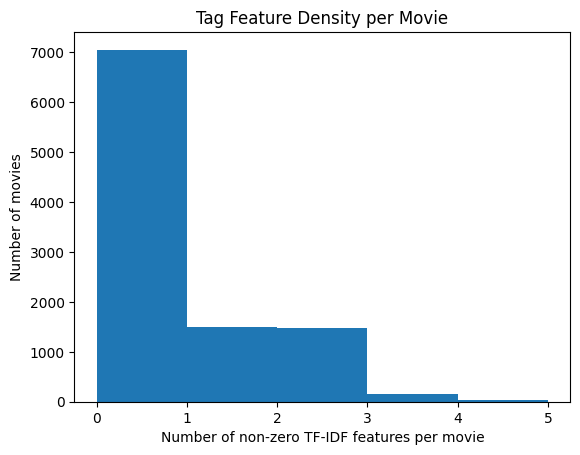

In [ ]:
# breaks later code 
if False: 
    tfidf = TfidfVectorizer(
        max_features=5000,
        stop_words="english"
    )

    tag_features = tfidf.fit_transform(movie_tags_weight_extension)

    print("Tag feature shape:", tag_features.shape)


    tag_sparsity = 1 - (
        tag_features.count_nonzero() /
        (tag_features.shape[0] * tag_features.shape[1])
    )

    print("Tag sparsity:", tag_sparsity)


    tag_counts = tag_features.getnnz(axis=1)

    plt.hist(tag_counts, bins=5)
    plt.xlabel("Number of non-zero TF-IDF features per movie")
    plt.ylabel("Number of movies")
    plt.title("Tag Feature Density per Movie")
    plt.show()

### Discussion
**Genre Feature**  
The Genre feature shape is (10197, 20) -> (movies, genres) and has a genre sparsity of 0.897965087770913. 
This is quite low in comparison to other sparsity matrices in recommender systems. This is mainly because the genres are only
20 predefined values and most of the movies will have genres because they are set by the site or movie producer. 


**Tag Feature**
The tag feature shape is (10197, 5000) -> (movies, tags) and has a lot more tags as the genre feature shape which results in 
a sparsity of 0.9985750514857311. I have also tried to implement another version where the tag weight is also incorporated into the analysis by repeating tags accordingly (e.g. tag weight 7 -> duplicate that line 7 times without the weight). 

In both cases the shape is the same but in the weighted case the emphasis is more on the tags which have a higher rating, the calculations lead to a smaller feature score as in comparison to the unweighted version. 

I also don't completely understand why there are only 5000 tags because there should be more, it seems to be some filtering of the TfidVectorizer. I tried to circumvent this by removing stop words, removing max words and adding a token_pattern which resulted in weird results thats why I removed it again. 

**Overall**   
The features differ significantly. While the genres provide a compact, interpretable and low dimensional representation they are limited in descriptive power because there are only limited genres. In contrast the tags offer a much more fine grained representation but come at the cost of a huge matrix and a very high sparsity. 




## c) user vector

In [20]:
def gen_user_vector(type="tags"): 
    positive_ratings = ratings[ratings["rating"] >= 4]

    user_pos_items = positive_ratings.groupby("userID")["movieID"].apply(list)

    movie_ids = movies["id"].values

    movie_index = {mid: idx for idx, mid in enumerate(movie_ids)}


    global_profile_tag = tag_features.mean(axis=0).reshape(1,-1)
    global_profile_genres = genre_features.mean(axis=0).reshape(1,-1)
    MIN_ITEMS = 2

    user_profiles = {}

    for user, items in user_pos_items.items():
        
        vectors = []
        
        for item in items:
            if item in movie_index:
                idx = movie_index[item]
                if type=="tags": 
                    vectors.append(tag_features[idx])
                else: 
                    vectors.append(genre_features[idx])
        
        if len(vectors) < MIN_ITEMS:
            if type=="tags": 
                user_profiles[user] = global_profile_tag 
            else: 
                user_profiles[user] = global_profile_genres
            continue
        
    
        user_profile = (sum(vectors) / len(vectors)).reshape(1,-1)
        
        user_profiles[user] = user_profile
    return user_profiles

In [21]:
user_profile_genres = gen_user_vector(type="genres")
user_profile_tags = gen_user_vector(type="tags")

In [22]:
first_user_tag = list(user_profile_tags.keys())[0]
tag_shape = np.shape(user_profile_tags[first_user_tag])

first_user_genre = list(user_profile_genres.keys())[0]
genre_shape = np.shape(user_profile_genres[first_user_genre])

print(f"Number of users with profiles: {len(user_profile_tags)}")
print("-" * 30)
print(f"Shape of tag-profile:   {tag_shape}")
print(f"Shape of genre-profils: {genre_shape}")

print("-" * 30)
print(f"Example genre for first user:  {first_user_genre}):")
print(user_profile_genres[first_user_genre])

Number of users with profiles: 2112
------------------------------
Shape of tag-profile:   (1, 3260)
Shape of genre-profils: (1, 20)
------------------------------
Example genre for first user:  75):
[[0.84615385 0.23076923 0.03846154 0.         0.23076923 0.38461538
  0.         0.38461538 0.07692308 0.03846154 0.03846154 0.
  0.03846154 0.03846154 0.03846154 0.23076923 0.         0.65384615
  0.07692308 0.        ]]


### Discussion
To handle users with no or not enough positive interactions we cann fallback by assigning the user a global profile. 
This could be handcrafted or just be set as the global average (as done in the code). The only problem could be if a user 
really dislikes the global average he continues to dislike the movies which are recommended to him which doesn't help him to break out of this standard recommendation because only positive interactions count towards it.   


The equation to calculate the user profile is:   
$u_u ​= \frac{1}{∣I_u^+| } \sum_{j∈I_u^+}x_j$  
This means we aggregate all tag vector for the user  
$v1 = [0,1,1,0]$    
$v2 = [1,1,0,1]$  
and then add them up and difide them by the sum of vectors (in this case two)  
$u_u = [1/2, 2/2, 1/2, 1/2]$  

## d) Cosine relevance

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

train_pos_ratings = train_ratings[train_ratings["rating"] >= 4]
user_train_items = train_pos_ratings.groupby("userID")["movieID"].apply(list)
def recommend_for_features(feature_matrix, feature_name):
    print(f"\n" + "="*50)
    print(f"analysis for: {feature_name}")
    print("="*50)

    movie_ids = movies["id"].values
    movie_index = {mid: idx for idx, mid in enumerate(movie_ids)}
    
    if not isinstance(feature_matrix, csr_matrix):
        feature_matrix = csr_matrix(feature_matrix)
    
    global_prof = feature_matrix.mean(axis=0)
    
    example_users = list(user_train_items.keys())[:3]
    
    for u_id in example_users:
        seen_in_train = train_ratings[train_ratings["userID"] == u_id]["movieID"].values
        pos_items = user_train_items[u_id]
        indices = [movie_index[m] for m in pos_items if m in movie_index]
        
        if len(indices) < 2:
            u_profile = np.asarray(global_prof)
        else:
            u_profile = np.asarray(feature_matrix[indices].mean(axis=0))
        
        sims = cosine_similarity(u_profile.reshape(1, -1), feature_matrix).flatten()
        sim_series = pd.Series(sims, index=movie_ids).drop(seen_in_train, errors='ignore')
        
        top_10_ids = sim_series.nlargest(10).index
        top_10_titles = movies[movies["id"].isin(top_10_ids)]["title"].values
        
        print(f"\nUser {u_id} (based on {len(pos_items)} positive films):")
        for i, title in enumerate(top_10_titles, 1):
            print(f"  {i}. {title}")

   

from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_grouped = movie_genres.groupby('movieID')['genre'].apply(list)
genre_matrix = mlb.fit_transform(movies['id'].map(genre_grouped).fillna('').apply(lambda x: x if isinstance(x, list) else []))

recommend_for_features(genre_matrix, "GENRES")
recommend_for_features(tag_features, "TAGS")



analysis for: GENRES

User 75 (based on 17 positive films):
  1. Heat
  2. Ninja Assassin
  3. Lawnmower Man 2: Beyond Cyberspace
  4. Screamers
  5. Johnny Mnemonic
  6. The Net
  7. Nemesis 2: Nebula
  8. Natural Born Killers
  9. Batman
  10. Black Moon Rising

User 78 (based on 302 positive films):
  1. Kicking & Screaming
  2. Big Bully
  3. Last Summer in the Hamptons
  4. In the Bleak Midwinter
  5. Keiner liebt mich
  6. Blue in the Face
  7. Jeffrey
  8. Love & Human Remains
  9. Smoke
  10. Southland Tales

User 127 (based on 13 positive films):
  1. From Dusk Till Dawn
  2. The Craft
  3. Carrie
  4. A Nightmare on Elm Street 3: Dream Warriors
  5. Poltergeist
  6. The Dead Zone
  7. The Witches of Eastwick
  8. Koroshiya 1
  9. Jigureul jikyeora!
  10. Gwoemul

analysis for: TAGS

User 75 (based on 17 positive films):
  1. La cité des enfants perdus
  2. Microcosmos: Le peuple de l'herbe
  3. La cérémonie
  4. Digging to China
  5. Broadcast News
  6. Final Fantasy: The Sp

## e) compare with baseline

In [27]:
def evaluate_with_baseline(genre_matrix, tag_features):
    popular_movies = train_ratings.groupby("movieID").size().sort_values(ascending=False)
    

    test_pos_ratings = test_ratings[test_ratings["rating"] >= 4]
    eval_users = test_pos_ratings["userID"].unique()

    movie_ids = movies["id"].values


    movie_index = {mid: idx for idx, mid in enumerate(movie_ids)}
    
    results = {}

    approaches = [
        ("GENRES", genre_matrix, False),
        ("TAGS", tag_features, False),
        ("MOST POPULAR", None, True)
    ]

    for name, matrix, is_baseline in approaches:
        print(f"\n" + "="*50)
        print(f"evaluation: {name}")
        print("="*50)
        
        hits = 0
        total_relevant_in_test = 0
        
        if not is_baseline and not isinstance(matrix, csr_matrix):
            matrix = csr_matrix(matrix)

        for u_id in eval_users:
            actual_relevant = test_pos_ratings[test_pos_ratings["userID"] == u_id]["movieID"].values
            total_relevant_in_test += len(actual_relevant)
            
            seen_in_train = train_ratings[train_ratings["userID"] == u_id]["movieID"].values
            
            if is_baseline:
                top_10_ids = popular_movies.drop(seen_in_train, errors='ignore').head(10).index
            else:
                pos_items_train = user_train_items.get(u_id, [])
                if not pos_items_train: continue
                
                indices = [movie_index[m] for m in pos_items_train if m in movie_index]
                u_profile = np.asarray(matrix[indices].mean(axis=0)).reshape(1, -1)
                
                sims = cosine_similarity(u_profile, matrix).flatten()
                top_10_ids = pd.Series(sims, index=movie_ids).drop(seen_in_train, errors='ignore').nlargest(10).index
            
            hits += len(set(top_10_ids) & set(actual_relevant))

        precision = hits / (len(eval_users) * 10)
        recall = hits / total_relevant_in_test if total_relevant_in_test > 0 else 0
        
        print(f"Hits: {hits}")
        print(f"Precision in top 10: {precision:.4f}")
        print(f"Recall in top 10:    {recall:.4f}")
        results[name] = (precision, recall)

    return results

eval_results = evaluate_with_baseline(genre_matrix, tag_features)


evaluation: GENRES
Hits: 285
Precision in top 10: 0.0137
Recall in top 10:    0.0038

evaluation: TAGS
Hits: 2605
Precision in top 10: 0.1251
Recall in top 10:    0.0346

evaluation: MOST POPULAR
Hits: 5628
Precision in top 10: 0.2702
Recall in top 10:    0.0747


### Discussion 
Precisicion -> how good are the recommendations  TP /TP+ FP   
recall -> how many were found  Tp /tp + FN

In this evaluation we can see that the best recommendation (according to numbers) is the Most Popular approach, after that tag based recommendation is second and genres is the least accurate (and precise).

The reason that tags are better than genre is probably that genres are way to broad, there are very different films in one genre and only if you like some of them that doesn't mean you will like the rest. 

The comparison with the baseline is also a bit unfair. Yes it is better in the way that the recommendations are most likely watched but they will not help the user find the real "gems". They will probably like the most popular movies but they will not absolutely love them. 



## f) cold start

In [30]:
cold_start_ratio = 0.1
all_movie_ids = movies['id'].unique()
np.random.seed(42)
cold_start_movie_ids = np.random.choice(all_movie_ids, size=int(len(all_movie_ids) * cold_start_ratio), replace=False)


train_ratings_cold = train_ratings[~train_ratings['movieID'].isin(cold_start_movie_ids)]

test_ratings_cold = test_ratings[test_ratings['movieID'].isin(cold_start_movie_ids) & (test_ratings['rating'] >= 4)]

def evaluate_cold_start(feature_matrix, feature_name):
    print(f"\n" + "="*50)
    print(f"COLD START EVALUATION: {feature_name}")
    print("="*50)
    
    movie_ids = movies["id"].values


    movie_index = {mid: idx for idx, mid in enumerate(movie_ids)}

    popular_movies = train_ratings_cold.groupby("movieID").size().sort_values(ascending=False)
    
    hits_cb = 0
    hits_pop = 0
    total_relevant = 0
    eval_users = test_ratings_cold['userID'].unique()
    
    for u_id in eval_users:
        actual_relevant = test_ratings_cold[test_ratings_cold['userID'] == u_id]['movieID'].values
        total_relevant +=len(actual_relevant)
        actual_relevant = test_ratings_cold[test_ratings_cold['userID'] == u_id]['movieID'].values
        seen_in_train = train_ratings_cold[train_ratings_cold['userID'] == u_id]['movieID'].values
        
        pos_items_train = train_ratings_cold[(train_ratings_cold['userID'] == u_id) & (train_ratings_cold['rating'] >= 4)]['movieID'].values
        if len(pos_items_train) > 0:
            indices = [movie_index[m] for m in pos_items_train if m in movie_index]
            u_profile = np.asarray(feature_matrix[indices].mean(axis=0)).reshape(1, -1)
            sims = cosine_similarity(u_profile, feature_matrix).flatten()
 

            sim_series = pd.Series(sims, index=movie_ids)
            top_10_cb = sim_series[sim_series.index.isin(cold_start_movie_ids)].nlargest(10).index
            hits_cb += len(set(top_10_cb) & set(actual_relevant))
        

        top_10_pop = popular_movies.drop(seen_in_train, errors='ignore').head(10).index
        hits_pop += len(set(top_10_pop) & set(actual_relevant))


    total_rec_count = len(eval_users) * 10
    
    prec_cb = hits_cb / total_rec_count if total_rec_count > 0 else 0
    recall_cb = hits_cb / total_relevant if total_relevant > 0 else 0
    
    prec_pop = hits_pop / total_rec_count if total_rec_count > 0 else 0
    recall_pop = hits_pop / total_relevant if total_relevant > 0 else 0

    print(f"Content-Based ({feature_name}): Hits: {hits_cb}, Precision: {prec_cb:.4f}, Recall: {recall_cb:.4f}")
    print(f"Most Popular Baseline:    Hits: {hits_pop}, Precision: {prec_pop:.4f}, Recall: {recall_pop:.4f}")




evaluate_cold_start(tag_features, "TAGS")
evaluate_cold_start(genre_features, "GENRES")


COLD START EVALUATION: TAGS
Content-Based (TAGS): Hits: 1121, Precision: 0.0639, Recall: 0.1325
Most Popular Baseline:    Hits: 0, Precision: 0.0000, Recall: 0.0000

COLD START EVALUATION: GENRES
Content-Based (GENRES): Hits: 382, Precision: 0.0218, Recall: 0.0452
Most Popular Baseline:    Hits: 0, Precision: 0.0000, Recall: 0.0000


## Diskussion
Here we remove the interactions for a set of films. 
Because of that they will not be recommended by most popular (never, maybe if you don't have any rated films). 
Therefore the content based recommendation is better because they have a starting point from the beginning.  

This is also realistic because new films will have no (or limited) user interactions. Genres and Tags on the other hand 
are (mostly) added by the platform or the authors of the material, this means they will already be available. 

The values for tags and genre based recommendation are worse than before because they are not able to recommend what they want but are restricted to the ones from the new set which 
hurts the overall performance. 